In [1]:
import pprint # Pretty print data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # statistical visualisation

#### Import dataset `dh_440.csv`
Target variables
- **`dh_pbe (eV/atom)`** — Formation enthalpy via PBE functional
- **`dh_hse (eV/atom)`** — Formation enthalpy via HSE06 functional

Features
- **`r_s (AA)`** — Wigner-Seitz radius (Å)
- **`r_val (AA)`** — Valence orbital radius (Å)
- **`e_H (eV)`** — HOMO / valence band maximum energy
- **`e_L (eV)`** — LUMO / conduction band minimum energy
- **`CE (eV/atom)`** — Cohesive energy per atom
- **`AN`** — Atomic number
- **`r_atom (pm)`** — Atomic radius
- **`r_cov (pm)`** — Covalent radius
- **`density (g/cm^3)`** — Mass density
- **`v_atom (cm^3/mol)`** — Molar volume
- **`N_val`** — Number of valence electrons
- **`N_unf`** — Number of unfilled valence orbitals
- **`DP (AA_polar^3)`** — Dipole polarizability
- **`EN (Pauling)`** — Pauling electronegativity
- **`EA (eV)`** — Electron affinity
- **`IP (eV)`** — Ionization potential
- **`H_fus (kJ/mol)`** — Enthalpy of fusion
- **`H_form (kJ/mol)`** — Enthalpy of formation
- **`MN`** — Magnetic moment (Bohr magnetons)
- **`C (J/g/K)`** — Specific heat capacity
- **`r_vdw (pm)`** — Van der Waals radius
- **`B_0 (GPa)`** — Bulk modulus
- **`min_dist (AA)`** — Minimum interatomic distance
- **`lat_para (AA)`** — Lattice parameter(s)
- **`volume (AA^3)`** — Unit cell volume
- **`CN`** — Coordination number
- **`OS`** — Oxidation state

In [2]:
df = pd.read_csv('dh_440.csv')
df.head()

,oxide,formula,dh_pbe (eV/atom),dh_hse (eV/atom),r_s (AA),r_val (AA),e_H (eV),e_L (eV),CE (eV/atom),AN,...,H_form (KJ/mol),MN,C (J/g/K),r_vdw (pm),B_0 (GPa),min_dist (AA),lat_para (AA),volume (AA^3),CN,OS
0,AgO,Ag4O4,-0.124,0.134,0.223850,0.220125,-2.162695,0.010354,-2.95,27.500000,...,267.064500,86.000000,0.658093,181.500000,88.053020,2.161426,8.649025,121.823516,1.000000,2.828427
1,Al2O3,Al4O6,-2.992,-3.198,0.156800,0.185410,-2.006619,0.155488,-3.39,10.000000,...,281.897400,92.600000,1.007512,164.800000,76.063625,1.878754,8.569691,88.175460,2.939388,3.535534
2,AlCuO2,AlCuO2,-2.057,-2.234,0.693238,0.764763,-6.352223,-0.445648,-6.88,14.500000,...,291.689500,88.500000,0.860843,171.000000,92.053020,1.929865,7.219037,41.250321,3.464102,2.683282
3,As2O5,As8O20,-1.041,-1.086,0.047082,0.052511,-0.677211,0.010006,-2.96,15.142857,...,264.449286,97.571429,0.864562,161.428571,60.647172,1.712168,13.254704,361.320322,4.356557,4.949747
4,Au2O3,Au4O6,-0.054,0.084,0.169590,0.166610,-1.863870,-0.117971,-3.81,36.400000,...,296.817400,88.600000,0.699112,176.800000,133.663625,1.983197,9.743922,139.383415,1.200000,3.683942


In [3]:
df.describe()

,dh_pbe (eV/atom),dh_hse (eV/atom),r_s (AA),r_val (AA),e_H (eV),e_L (eV),CE (eV/atom),AN,r_atom (pm),r_cov (pm),...,H_form (KJ/mol),MN,C (J/g/K),r_vdw (pm),B_0 (GPa),min_dist (AA),lat_para (AA),volume (AA^3),CN,OS
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,...,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,-1.888834,-2.023318,0.241101,0.185111,-1.672000,0.134016,-6.182070,19.000535,153.382649,101.410435,...,295.860510,78.636627,0.859183,181.549337,86.607836,1.944047,12.487981,311.824224,3.544248,3.213194
std,0.834307,0.911481,0.230931,0.205992,1.567000,0.276153,3.222011,7.906075,16.476872,23.410233,...,74.160738,13.858785,0.243478,20.730819,29.115186,0.431044,3.963141,271.629072,1.340461,1.499058
min,-3.602000,-3.836000,0.029368,0.019827,-9.155805,-0.483526,-16.930000,4.666667,129.100710,69.444444,...,98.091125,19.625000,0.274170,152.500000,10.913255,1.229545,5.176552,18.899008,0.000000,0.000000
25%,-2.569000,-2.776250,0.100425,0.067291,-1.805141,0.014861,-8.030000,13.370536,144.261678,86.918860,...,253.905774,72.486111,0.778557,170.729167,66.948145,1.729933,9.848714,142.676107,2.869765,2.683282
50%,-1.909500,-2.042500,0.164857,0.115035,-1.125684,0.054411,-5.950000,17.183333,148.590386,94.285714,...,298.020449,82.625000,0.838008,175.200000,87.131805,1.884247,12.144488,254.688392,3.771236,3.535534
75%,-1.284500,-1.408250,0.279558,0.198838,-0.696548,0.144189,-3.890000,23.000000,156.379231,108.000000,...,338.436316,87.737762,0.891901,184.425000,103.691276,1.994545,14.812624,422.900407,4.396969,4.242641
max,0.024000,0.270000,1.332150,1.317250,-0.261403,2.524395,0.000000,63.714286,251.900178,235.000000,...,705.889857,99.250000,2.685729,319.125000,203.812281,5.181868,32.447398,3025.138962,6.734983,7.071068


In [4]:
# Get the list of feature columns
blacklist = ['dh_hse (eV/atom)','dh_pbe (eV/atom)','formula','oxide']
feature_cols = [col for col in list(df.columns) if col not in blacklist]

# Get array of features
x = df[feature_cols].values

# Get array of target variables
y_1 = df['dh_hse (eV/atom)']
y_2 = df['dh_pbe (eV/atom)']

print(f'shape of x: {x.shape}')
print(f'shape of y_hse: {y_1.shape}')
print(f'shape of y_pbe: {y_2.shape}')

shape of x: (440, 27)
shape of y_hse: (440,)
shape of y_pbe: (440,)


In [5]:
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve

def make_prediction_plot(x, y, y_pred, model):
    '''
    Plot predictions for the given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    y_pred: Predicted values.
    model: Fitted model.
    '''
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.scatter(y, y_pred, c=y, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {y.name}')
    ax.set_ylabel(f'predicted {y.name}')
    ax.set_title(f'{y.name} {model.__class__.__name__} prediction plot')
    plt.show()
    print('Training scores:')
    print (f'MAE = {metrics.mean_absolute_error(y,y_pred):.3f}')
    print(f'RMSE = {metrics.root_mean_squared_error(y,y_pred):.3f}')
    print(f'r^2 = {model.score(x,y):.3f}')

def print_cross_val(x, y, model, n_splits=10, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    model: Fitted model.
    n_splits: number of cv splits.
    random_state: random state.
    '''
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
    }
    results = cross_validate(model, x, y, cv=cv, scoring=scoring_metrics)
    
    print('Cross-validation scores:')
    print(f'Mean MAE = {np.mean(np.abs(results['test_mae'])):.3f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.3f}')
    print(f'Mean r^2 = {np.mean(results['test_r2']):.3f}')

def make_learning_curve_plot(x, y, model):
    '''
    Plot 'r2' traininlearning curve for given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    model: Fitted model.
    '''
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=x,
        y=y,
        train_sizes=np.arange(0.1, 1.0, 0.1),    # [0.1, 0.2, 0.3, ..., 0.9]
        cv=10,                                   # 10-fold cross-validation
        scoring="r2",                            # or "r2", "neg_mean_absolute_error", etc.
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )
    
    train_sizes_pct = np.arange(0.1, 1.0, 0.1)
    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_mean = test_scores.mean(axis=1)
    test_scores_std = test_scores.std(axis=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.errorbar(
        train_sizes_pct, train_scores_mean,
        yerr=train_scores_std,
        fmt="o-", color="steelblue", capsize=4, label="Training r^2"
    )
    
    ax.errorbar(
        train_sizes_pct, test_scores_mean,
        yerr=test_scores_std,
        fmt="o-", color="tomato", capsize=4, label="Test r^2"
    )
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("r^2")
    ax.set_title(f'{y.name} {model.__class__.__name__} learning curve')
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

### Data preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

# Impute & Scale
imputer = SimpleImputer(strategy="mean")
x = imputer.fit_transform(x)

scaler = StandardScaler()
x = scaler.fit_transform(x)

# Feature Selection
# k_1=10
# selector_1 = SelectKBest(score_func=f_regression, k=k_1)
# x_1 = selector_1.fit_transform(x, y_1)

# k_2=10
# selector_2 = SelectKBest(score_func=f_regression, k=k_2)
# x_2 = selector_2.fit_transform(x, y_2)

In [7]:
# Import models
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

### Random Forest

#### hse

In [8]:
rf_1 = RandomForestRegressor(
    n_estimators=300,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2,  
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_1.fit(x,y_1)
y_1_rf = rf_1.predict(x)

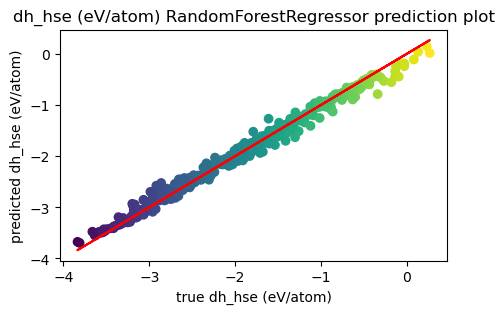

Training scores:
MAE = 0.080
RMSE = 0.108
r^2 = 0.986


In [9]:
make_prediction_plot(x, y_1, y_1_rf, rf_1)

In [10]:
print_cross_val(x, y_1, rf_1)

Cross-validation scores:
Mean MAE = 0.228
Mean RMSE = 0.304
Mean r^2 = 0.882


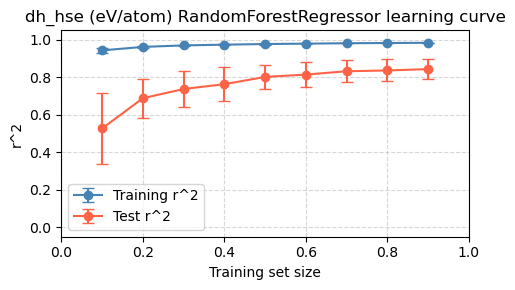

In [11]:
make_learning_curve_plot(x, y_1, rf_1)

#### pbe

In [12]:
rf_2 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_2.fit(x,y_2)
y_2_rf = rf_2.predict(x)

In [2]:
data

NameError: name 'data' is not defined

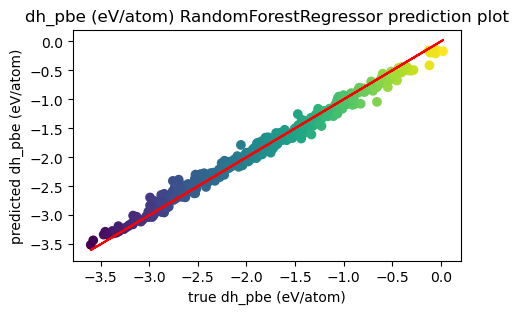

Training scores:
MAE = 0.069
RMSE = 0.094
r^2 = 0.987


In [13]:
make_prediction_plot(x, y_2, y_2_rf, rf_2)

In [14]:
print_cross_val(x, y_2, rf_2)

Cross-validation scores:
Mean MAE = 0.194
Mean RMSE = 0.261
Mean r^2 = 0.896


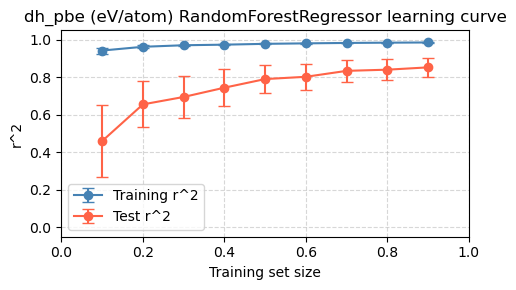

In [15]:
make_learning_curve_plot(x, y_2, rf_2)

### Kernel Ridge

#### hse

In [16]:
kr_1 = KernelRidge(
    alpha=0.01,
    gamma=0.01,
    kernel='laplacian',
)
kr_1.fit(x,y_1)
y_1_kr = kr_1.predict(x)

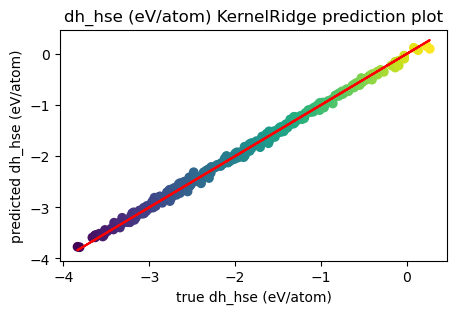

Training scores:
MAE = 0.038
RMSE = 0.048
r^2 = 0.997


In [17]:
make_prediction_plot(x, y_1, y_1_kr, kr_1)

In [18]:
print_cross_val(x, y_1, kr_1)

Cross-validation scores:
Mean MAE = 0.191
Mean RMSE = 0.258
Mean r^2 = 0.914


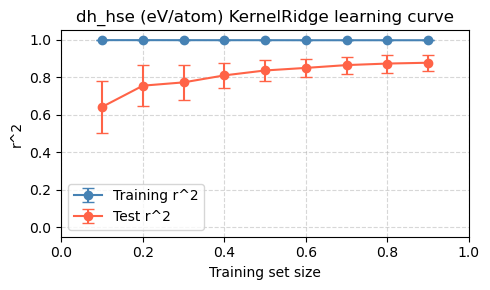

In [19]:
make_learning_curve_plot(x, y_1, kr_1)

#### pbe

In [20]:
kr_2 = KernelRidge(
    alpha=0.01,
    gamma=0.01,
    kernel='laplacian',
)
kr_2.fit(x,y_2)
y_2_kr = kr_2.predict(x)

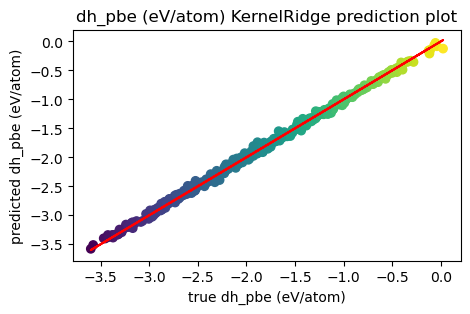

Training scores:
MAE = 0.031
RMSE = 0.041
r^2 = 0.998


In [21]:
make_prediction_plot(x, y_2, y_2_kr, kr_2)

In [22]:
print_cross_val(x, y_2, kr_2)

Cross-validation scores:
Mean MAE = 0.161
Mean RMSE = 0.221
Mean r^2 = 0.924


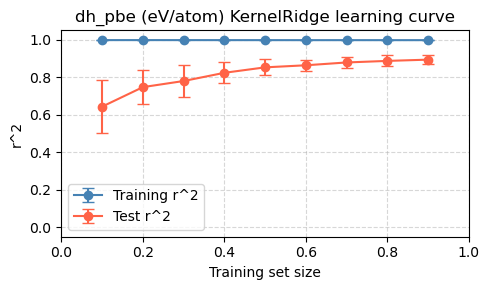

In [23]:
make_learning_curve_plot(x, y_2, kr_2)

### XGBoost

#### hse

In [24]:
xgb_1 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    n_estimators=500,
    reg_alpha=0.1,
    reg_lambda=5.0,
    subsample=0.6,
)
xgb_1.fit(x,y_1)
y_1_xgb = xgb_1.predict(x)

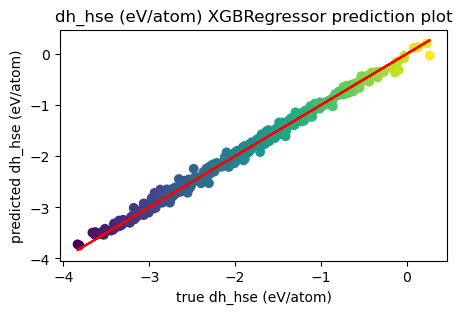

Training scores:
MAE = 0.056
RMSE = 0.073
r^2 = 0.994


In [25]:
make_prediction_plot(x, y_1, y_1_xgb, xgb_1)

In [26]:
print_cross_val(x, y_1, xgb_1)

Cross-validation scores:
Mean MAE = 0.197
Mean RMSE = 0.265
Mean r^2 = 0.911


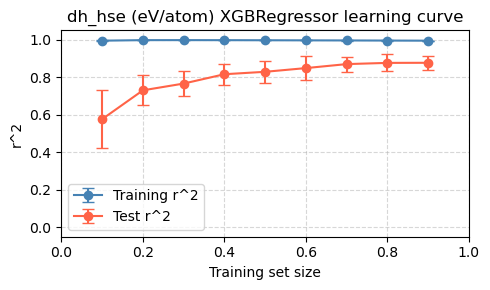

In [27]:
make_learning_curve_plot(x, y_1, xgb_1)

#### pbe

In [28]:
xgb_2 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=10,
    n_estimators=500,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
)
xgb_2.fit(x,y_2)
y_2_xgb = xgb_2.predict(x)

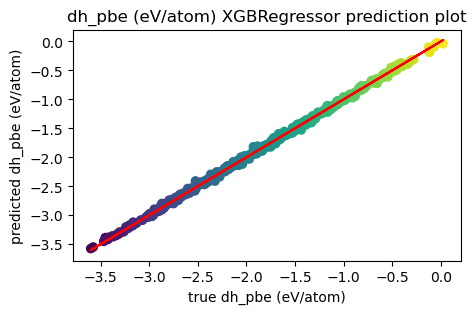

Training scores:
MAE = 0.022
RMSE = 0.028
r^2 = 0.999


In [29]:
make_prediction_plot(x, y_2, y_2_xgb, xgb_2)

In [30]:
print_cross_val(x, y_2, xgb_2)

Cross-validation scores:
Mean MAE = 0.168
Mean RMSE = 0.228
Mean r^2 = 0.919


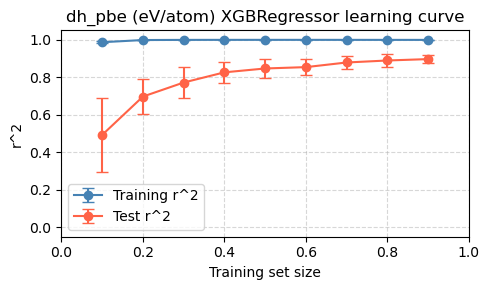

In [31]:
make_learning_curve_plot(x, y_2, xgb_2)

### Violins plots

In [32]:
# Define models
models = [
    rf_1,
    kr_1,
    xgb_1,
]

# Run CV for each model
records = []
for model in models:
    scores = cross_val_score(
        estimator=model,
        X=x,
        y=y_1,
        cv=10,
        scoring='r2',
        n_jobs=-1,
    )
    for score in scores:
        records.append({'Model': model.__class__.__name__, 'r^2': score})

df_plot_1 = pd.DataFrame(records) # Make dataframe from CV scores

In [33]:
# Define models
models = [
    rf_2,
    kr_2,
    xgb_2,
]

# Run CV for each model
records = []
for model in models:
    scores = cross_val_score(
        estimator=model,
        X=x,
        y=y_2,
        cv=10,
        scoring='r2',
        n_jobs=-1,
    )
    for score in scores:
        records.append({'Model': model.__class__.__name__, 'r^2': score})

df_plot_2 = pd.DataFrame(records) # Make dataframe from CV scores

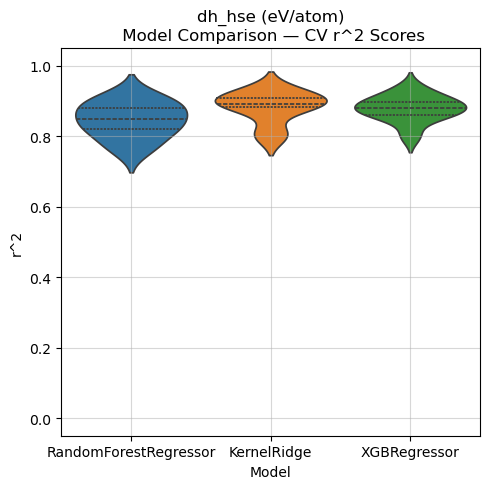

In [34]:
# Plot
fig, ax = plt.subplots(figsize=(5, 5))

sns.violinplot(
    data=df_plot_1,
    y='r^2',
    x='Model',
    hue='Model',
    inner='quartile',
    legend=False,
    ax=ax,
)

ax.set_title(f'{y_1.name}\n Model Comparison — CV r^2 Scores')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

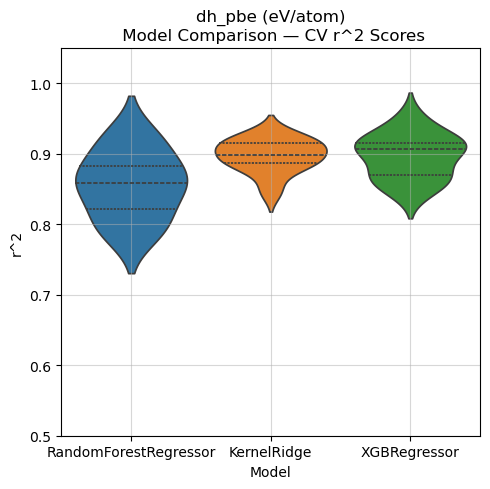

In [37]:
# Plot
fig, ax = plt.subplots(figsize=(5, 5))

sns.violinplot(
    data=df_plot_2,
    y='r^2',
    x='Model',
    hue='Model',
    inner='quartile',
    legend=False,
    ax=ax,
)

ax.set_title(f'{y_2.name}\n Model Comparison — CV r^2 Scores')
ax.set_ylim(0.5, 1.05)
ax.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()